<a href="https://colab.research.google.com/github/Herrera1022/Modelo_afluencia_metro_pruebas/blob/main/knn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Clonar el repositorio
!git clone https://github.com/Herrera1022/Modelo_afluencia_metro_pruebas.git

# Entrar a la carpeta
import os
os.chdir("Modelo_afluencia_metro_pruebas")

# Verificar que los archivos estén
!ls

Cloning into 'Modelo_afluencia_metro_pruebas'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 107 (delta 61), reused 65 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 13.60 MiB | 9.42 MiB/s, done.
Resolving deltas: 100% (61/61), done.
 afluencia_metro_2024_transformado.csv	'Paper primera entrega.pdf'   splits
 Afluencia_Metro_2024.xlsx		 README.md
 Exploracion_inicial.ipynb		 regresion.ipynb


# Modelo 2: KNN (K-Nearest Neighbors Regressor)


In [2]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.utils import resample
import matplotlib.pyplot as plt

In [3]:
X_train      = pd.read_csv("./splits/X_train.csv")
y_train      = pd.read_csv("./splits/y_train.csv").squeeze()

X_validation = pd.read_csv("./splits/X_validation.csv")
y_validation = pd.read_csv("./splits/y_validation.csv").squeeze()

X_test       = pd.read_csv("./splits/X_test.csv")
y_test       = pd.read_csv("./splits/y_test.csv").squeeze()

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_validation.shape}")
print(f"Test:       {X_test.shape}")

Train:      (59899, 22)
Validation: (6947, 22)
Test:       (13611, 22)


## Búsqueda de hiperparámetros (Grid Search manual)
Probamos diferentes valores de K y el tipo de ponderación para encontrar la mejor combinación según el RMSE en validación.

In [4]:
# Malla de hiperparámetros
k_values = [3, 5, 10, 20, 50]
weight_options = ["uniform", "distance"]

resultados = []

for k in k_values:
    for w in weight_options:
        print(f"Probando K={k}, weights={w}...")

        modelo = KNeighborsRegressor(n_neighbors=k, weights=w, n_jobs=-1)
        modelo.fit(X_train, y_train)

        pred_train = modelo.predict(X_train)
        pred_val   = modelo.predict(X_validation)

        rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
        rmse_val   = np.sqrt(mean_squared_error(y_validation, pred_val))
        mape_val   = mean_absolute_percentage_error(y_validation, pred_val) * 100

        resultados.append({
            "K": k,
            "weights": w,
            "RMSE_train": round(rmse_train, 2),
            "RMSE_val":   round(rmse_val, 2),
            "MAPE_val":   round(mape_val, 2)
        })

        print(f"  → RMSE train: {rmse_train:.2f} | RMSE val: {rmse_val:.2f} | MAPE val: {mape_val:.2f}%")

df_resultados = pd.DataFrame(resultados)
print("\n=== RESULTADOS COMPLETOS ===")
print(df_resultados.sort_values("RMSE_val"))

Probando K=3, weights=uniform...
  → RMSE train: 691.27 | RMSE val: 1095.83 | MAPE val: 30.81%
Probando K=3, weights=distance...
  → RMSE train: 0.11 | RMSE val: 1107.19 | MAPE val: 28.28%
Probando K=5, weights=uniform...
  → RMSE train: 825.62 | RMSE val: 1073.23 | MAPE val: 60.11%
Probando K=5, weights=distance...
  → RMSE train: 0.11 | RMSE val: 1085.54 | MAPE val: 33.95%
Probando K=10, weights=uniform...
  → RMSE train: 1047.68 | RMSE val: 1001.62 | MAPE val: 64.85%
Probando K=10, weights=distance...
  → RMSE train: 0.11 | RMSE val: 1066.58 | MAPE val: 39.04%
Probando K=20, weights=uniform...
  → RMSE train: 1292.57 | RMSE val: 999.25 | MAPE val: 79.57%
Probando K=20, weights=distance...
  → RMSE train: 0.11 | RMSE val: 1020.38 | MAPE val: 48.88%
Probando K=50, weights=uniform...
  → RMSE train: 1581.96 | RMSE val: 1203.13 | MAPE val: 197.45%
Probando K=50, weights=distance...
  → RMSE train: 0.11 | RMSE val: 1046.63 | MAPE val: 93.19%

=== RESULTADOS COMPLETOS ===
    K   weights 

## Modelo final con mejores hiperparámetros: K=20, weights=uniform

In [8]:

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score

# Entrenar modelo final con mejores hiperparámetros
modelo_final = KNeighborsRegressor(n_neighbors=20, weights="uniform", n_jobs=-1)
modelo_final.fit(X_train, y_train)


# Predicciones
pred_train = modelo_final.predict(X_train)
pred_val   = modelo_final.predict(X_validation)
pred_test  = modelo_final.predict(X_test)

# RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_val   = np.sqrt(mean_squared_error(y_validation, pred_val))
rmse_test  = np.sqrt(mean_squared_error(y_test, pred_test))

# MAE
mae_train = mean_absolute_error(y_train, pred_train)
mae_val   = mean_absolute_error(y_validation, pred_val)
mae_test  = mean_absolute_error(y_test, pred_test)

# MAPE
mape_train = mean_absolute_percentage_error(y_train, pred_train) * 100
mape_val   = mean_absolute_percentage_error(y_validation, pred_val) * 100
mape_test  = mean_absolute_percentage_error(y_test, pred_test) * 100

# R²
r2_train = r2_score(y_train, pred_train)
r2_val   = r2_score(y_validation, pred_val)
r2_test  = r2_score(y_test, pred_test)

print("=== MÉTRICAS MODELO FINAL KNN (K=20, uniform) ===")
print(f"{'Métrica':<8} {'Train':>10} {'Validación':>12} {'Test':>10}")
print("-" * 44)
print(f"{'RMSE':<8} {rmse_train:>10.2f} {rmse_val:>12.2f} {rmse_test:>10.2f}")
print(f"{'MAE':<8} {mae_train:>10.2f} {mae_val:>12.2f} {mae_test:>10.2f}")
print(f"{'MAPE':<8} {mape_train:>9.2f}% {mape_val:>11.2f}% {mape_test:>9.2f}%")
print(f"{'R²':<8} {r2_train:>10.4f} {r2_val:>12.4f} {r2_test:>10.4f}")

=== MÉTRICAS MODELO FINAL KNN (K=20, uniform) ===
Métrica       Train   Validación       Test
--------------------------------------------
RMSE        1292.57       999.25    1351.65
MAE          288.51       229.01     389.05
MAPE        192.84%       79.57%     90.24%
R²           0.9828       0.9907     0.9823


In [6]:
# Bootstrap sobre validación para calcular intervalo de confianza del RMSE
n_bootstrap = 500
rmse_bootstrap = []

for i in range(n_bootstrap):
    # Muestra aleatoria con reemplazo del conjunto de validación
    indices = resample(range(len(y_validation)), random_state=i)
    rmse_b = np.sqrt(mean_squared_error(
        y_validation.iloc[indices],
        pred_val[indices]
    ))
    rmse_bootstrap.append(rmse_b)

ic_lower = np.percentile(rmse_bootstrap, 2.5)
ic_upper = np.percentile(rmse_bootstrap, 97.5)

print(f"RMSE Validación: {rmse_val:.2f}")
print(f"Intervalo de confianza 95%: [{ic_lower:.2f}, {ic_upper:.2f}]")
print(f"Expresado como: {rmse_val:.2f} ± {((ic_upper - ic_lower)/2):.2f}")

RMSE Validación: 999.25
Intervalo de confianza 95%: [745.17, 1231.13]
Expresado como: 999.25 ± 242.98


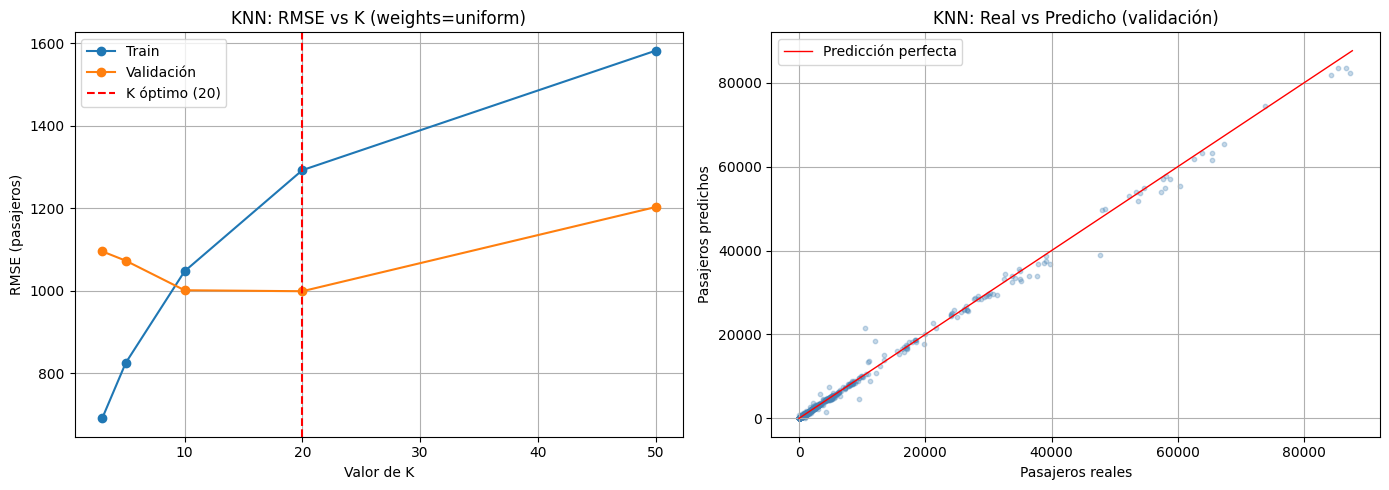

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: RMSE por valor de K (solo uniform)
df_uniform = df_resultados[df_resultados["weights"] == "uniform"]
axes[0].plot(df_uniform["K"], df_uniform["RMSE_train"], marker="o", label="Train")
axes[0].plot(df_uniform["K"], df_uniform["RMSE_val"],   marker="o", label="Validación")
axes[0].axvline(x=20, color="red", linestyle="--", label="K óptimo (20)")
axes[0].set_xlabel("Valor de K")
axes[0].set_ylabel("RMSE (pasajeros)")
axes[0].set_title("KNN: RMSE vs K (weights=uniform)")
axes[0].legend()
axes[0].grid(True)

# Gráfica 2: Real vs Predicho en validación
sample_idx = np.random.choice(len(y_validation), size=1000, replace=False)
axes[1].scatter(
    y_validation.iloc[sample_idx],
    pred_val[sample_idx],
    alpha=0.3, s=10, color="steelblue"
)
max_val = max(y_validation.max(), pred_val.max())
axes[1].plot([0, max_val], [0, max_val], color="red", linewidth=1, label="Predicción perfecta")
axes[1].set_xlabel("Pasajeros reales")
axes[1].set_ylabel("Pasajeros predichos")
axes[1].set_title("KNN: Real vs Predicho (validación)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()